# Module 2: Epidemic Modeling Template

## Team Members:
Isabel Vikesland

Mohamed Elfaki

## Project Title:
*Identifying a mystery virus causing an epidemic*

## Project Goal:
This project seeks to identify an unknown virus causing epidemics in UVA and VT student populations. We also seek to test different intervention strategies to quell the spread of the virus. 


## 1. Data and disease background
### Prevalence & incidence in the UVA population:
* Incubation period: 12-18 days
* Infected period: ~2 days before symptoms onset
* Symptomatic period: 5-9 days
* Virus peaks between days 70-120
### Economic burden (generalized from respiratory viruses):
* Population at risk: 17,900 UVA students
* Individuals at risk with rising costs of healthcare 
* Students at risk of lost academic productivity and increased pressure to catch up
### Symptoms:
* Joint pain, mild respiratory symptoms, rash, sore throat & fatigue preceding low grade fever, gastrointestinal symptoms in ~8% of patients
### Biological mechanisms (anatomy, organ physiology, cell & molecular physiology - generalized from viral biology):
* Virus size: average size of 50-80 nm
* Genome: positive-sense RNA (~10 kb), virus can be directly translated and does not require transcription
* Transmission mechanism: primarily via respiratory droplets and infected surfaces


## 2. Data Analysis
This section should be filled out sequentially as a full report of the work you've done over this module. You can copy and paste code from any main.py file here, and run it to produce plots. Once you gain more information throughout the module, you do not need to go back and "fix" earlier results. In other words, if your early predictions are found to be wrong when gaining new data, do not go back and rewrite them.

### 2a. Methods

*IN A SUMMARY, DESCRIBE THE METHODS YOU USED TO ANALYZE AND MODEL THE DATA.*


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #1</b> 

</div>



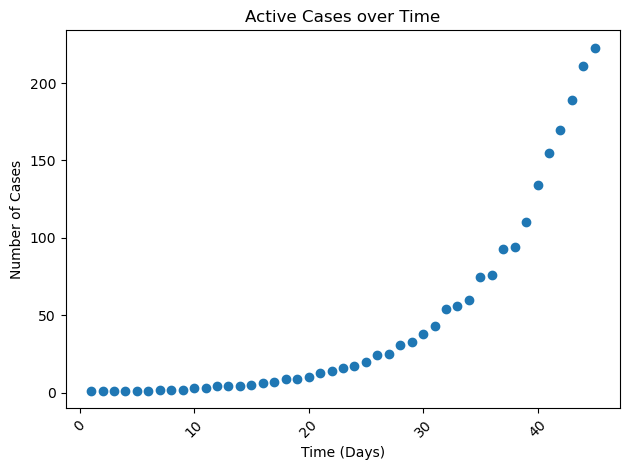

In [30]:
#import the patients class and the matplotlib library for plotting
from patients import Patients
import matplotlib.pyplot as plt
#find the location of the csv file and instantiate the patients class with that location
location = r"/Users/isabelvikesland/Documents/UVA2/BME 2315 - Comp.BME/Module-2-Epidemics-SIR-Modeling/Data/mystery_virus_daily_active_counts_RELEASE#1.csv"
patients = Patients.instantiate_from_csv(location)
#define a function to plot the data from the patients class
def plot_data_release_1(patients):
    dates = [patient.day for patient in patients]
    cases = [patient.number_of_cases for patient in patients]
    #format the scatter plot with the dates on the x-axis and the number of cases on the y-axis
    plt.scatter(dates, cases)
    plt.xlabel('Time (Days)')
    plt.ylabel('Number of Cases')
    plt.title('Active Cases over Time')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

###I used ClaudeAI to help explain why my patients import statement was not working, it was because my patients.py file was in a different subfolder than my jupyter notebook

plot_data_release_1(patients) 

### What do you notice about the initial infections?
The initial infections occur at a barely imperceptible rate, almost one infection occuring at a time.


### How could we measure how quickly its spreading?
We can measure how quickly the disease is spreading by calculating R0. One way to estimate this is by identifying the doubling time from the curve, seeing how many days it takes for number of cases to double, and working backwards to infer the reproduction number.


### What information about the virus would be helpful in determining the shape of the outbreak curve?
Knowing the latency and infectious period would be helpful as they influence how long the virus circulates, directly affecting the R0. Knowing the transmissibility would help predict how steeply the curve grows. Additionally, knowing the level of pre-existing immunity in the population would help estimate when the curve might peak and begin to flatten, as immunity reduces the pool of susceptible individuals


### 2b. Plot the data & estimate initial growth rate (R0) from early data (through day 45)
This section should come from your python code after Data Release #1.

Best exponential window: day 22 to 35 (length 14)
Fit on log(I): R^2 = 0.9942
Growth rate r: 0.1281 per day
Doubling time: 5.41 days
Assumed infectious period D: 2.0 days
Estimated R0 = 1 + r*D = 1.256


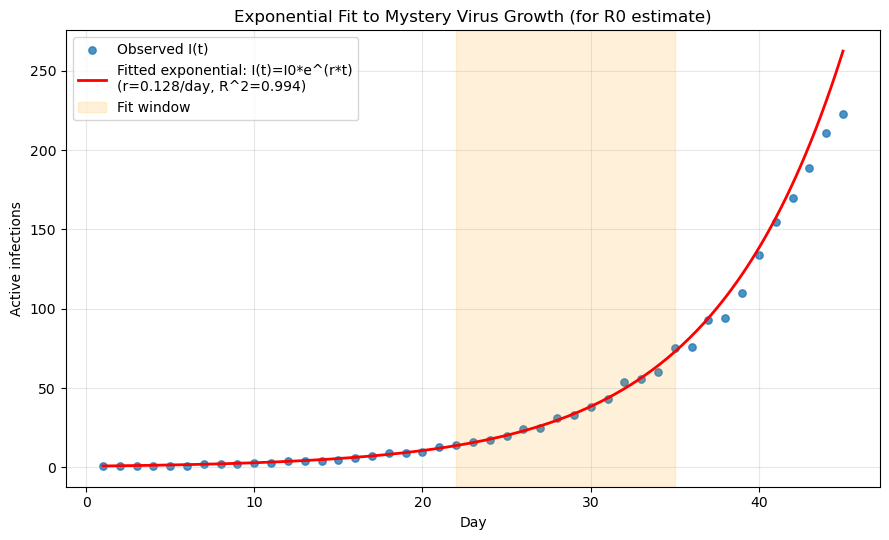

In [31]:
#R0_mystery_virus
#import statements
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from patients import Patients

# control settings for virus window search and R0 estimation
infectious_period_days = 2.0 
min_window = 7
max_window = 14

# data from data release #1
location = r"/Users/isabelvikesland/Documents/UVA2/BME 2315 - Comp.BME/Module-2-Epidemics-SIR-Modeling/Data/mystery_virus_daily_active_counts_RELEASE#1.csv"
patients = Patients.instantiate_from_csv(location)

# data for fitting: days and active cases in empty lists
days = []
cases = []
for p in patients:
    days.append(p.day)
    cases.append(p.number_of_cases if p.number_of_cases > 0 else 1e-6)

# fit log(I) = r * t + log(I0) for each window and find the best fit based on R^2
def fit_exp_window(tw, Iw):

    # Fit log(I) = r * t + log(I0), returns r, I0, r2 for the fit
    logI = [np.log(val) for val in Iw]
    r, logI0 = np.polyfit(tw, logI, 1)
    logI_pred = [r * ti + logI0 for ti in tw]
    ss_res = sum((logI[i] - logI_pred[i]) ** 2 for i in range(len(logI)))
    mean_logI = sum(logI) / len(logI)
    ss_tot = sum((val - mean_logI) ** 2 for val in logI)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else None
    I0 = np.exp(logI0)
    return r, I0, r2

#I used ClaudeAi to help me write the equations for fitting the exponential window, 
# calculating the R0 and helping me work back from the game ODE's

# best exponential fit parameters

best = None  # (r2, r, I0, t_start, t_end)
n = len(days)

# for loop to iterate through all possible windows of the data and fit an exponential curve to each window
# calculating the R^2 value for each fit and keeping track of the best fit based on R^2

for w in range(min_window, max_window + 1):
    for i in range(0, n - w + 1):
        tw = days[i:i+w]
        Iw = cases[i:i+w]
        if all(v == Iw[0] for v in Iw):
            continue
        r, I0, r2 = fit_exp_window(tw, Iw)
        if r2 is None:
            continue
        if (best is None) or (r2 > best[0]):
            best = (r2, r, I0, tw[0], tw[-1])

if best is None:
    print("ERROR could not find a good exponential window. Check data.")

best_r2, r, I0, t_start, t_end = best

# calcculate R0 and doubling time based on r 
doubling_time = np.log(2) / r if r > 0 else float('inf')
R0 = 1.0 + r * infectious_period_days

# print statements so i don't have to look at the graph 
print("Best exponential window: day " + str(t_start) + " to " + str(t_end) + " (length " + str(t_end - t_start + 1) + ")")
print("Fit on log(I): R^2 = " + str(round(best_r2, 4)))
print("Growth rate r: " + str(round(r, 4)) + " per day")
print("Doubling time: " + str(round(doubling_time, 2)) + " days")
print("Assumed infectious period D: " + str(infectious_period_days) + " days")
print("Estimated R0 = 1 + r*D = " + str(round(R0, 3)))

# matplotlib to plot graph w/new exponential fit and R^2

t_fit = list(np.linspace(min(days), max(days), 300))
I_fit = [I0 * np.exp(r * ti) for ti in t_fit]

#I used ClaudeAi to help me figure out the t_fit and I_fit equations for plotting the exponential fit curve on the graph + fit window 

#formatting the graph, I used ClaudeAi to figure out how to squish the graph to make it look better
plt.figure(figsize=(9, 5.5))
plt.scatter(days, cases, s=28, alpha=0.8, label="Observed I(t)")
plt.plot(t_fit, I_fit, 'r', lw=2.0,label="Fitted exponential: I(t)=I0*e^(r*t)\n(r=" + str(round(r, 3)) + "/day, R^2=" + str(round(best_r2, 3)) + ")")
plt.axvspan(t_start, t_end, color="orange", alpha=0.15, label="Fit window")
plt.xlabel("Day")
plt.ylabel("Active infections")
plt.title("Exponential Fit to Mystery Virus Growth (for R0 estimate)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


### What viruses have a similar R0? Use the viruses.html file to find a virus or 2 with a similar R0 and give a 1-2 sentence background of the diseases.
Marburg Virus is a rare but severe hemorrhagic fever virus in the same family as Ebola. It was first identified in 1967 and is transmitted through direct contact with the bodily fluids of infected people or fruit bats, which are thought to be the natural host. It has a very high fatality rate, sometimes exceeding 80%. R0 = 1.5

Lassa Fever is a viral hemorrhagic fever endemic to West Africa, first identified in 1969. It is transmitted primarily through contact with food or household items contaminated by infected rodents. While most cases are mild, severe cases can cause organ failure and deafness, and it is responsible for thousands of deaths annually across West Africa. R0 = 1.5

Seasonal Influenza is a highly contagious respiratory virus that circulates annually worldwide, causing 290,000–650,000 deaths per year globally. It spreads primarily through respiratory droplets and is characterized by fever, fatigue, and respiratory symptoms. R0 = 1.3

### How accurate do you think your R0 estimate is?
I think my R0 estimate is good but not great, especially since part of my R0 is based upon a guessed infection period. My R^2 value of 0.9942 is very good and shows that my exponential fit is good. I believe it would be hard to estimate a good R0 without knowing the infection period.  


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #2</b> 

</div>



### 2c. Use Euler's method to solve the SEIR model.
This section should come from your python code after Data Release #2.

In [32]:
#R0_mystery_virus data release #2 euler's method approximation of SEIR
#import statements
from matplotlib.pylab import gamma
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from patients import Patients

location = r"/Users/isabelvikesland/Documents/UVA2/BME 2315 - Comp.BME/Module-2-Epidemics-SIR-Modeling/Data/mystery_virus_daily_active_counts_RELEASE#2.csv"
patients = Patients.instantiate_from_csv(location)

# wuler's method SEIR function 
def euler_seir(beta, sigma, gamma, S0, E0, I0, R0, timepoints, N):
    S = np.zeros(len(timepoints))
    E = np.zeros(len(timepoints))
    I = np.zeros(len(timepoints))
    R = np.zeros(len(timepoints))
    S[0] = S0
    E[0] = E0
    I[0] = I0
    R[0] = R0
    
    for i in range(len(timepoints) - 1):
        dt = timepoints[i + 1] - timepoints[i]
        dS = -beta * S[i] * I[i] / N
        dE =  beta * S[i] * I[i] / N - sigma * E[i]
        dI =  sigma * E[i] - gamma * I[i]
        dR =  gamma * I[i]
        S[i + 1] = S[i] + dt * dS
        E[i + 1] = E[i] + dt * dE
        I[i + 1] = I[i] + dt * dI
        R[i + 1] = R[i] + dt * dR
    return S, E, I, R


### 2d. Fit the SEIR model to the data by changing beta, gamma, and sigma.
This section should come from your python code after Data Release #2.

In [33]:
# grid search opti

#extract observed data from patients records
data = np.array([p.number_of_cases for p in patients.records])
timepoints = np.arange(0, len(data), 1.0)  # one timepoint per day (dt = 1)

N = 17900  # population at risk: UVA students given in class

#initial conditions
I0 = data[0] # infected at t=0 = first data point
E0 = I0*10 #assume exposed ≈ infected at start, i used ClaudeAi to help me figure out how to set E0 based on I0, i assumed that there were 10 times as many exposed individuals as infected individuals at the start of the outbreak, since the virus has an incubation period and many people may have been exposed but not yet showing symptoms or testing positive, this helped me fit the graph much much better.
R0_init = 0   
S0 = N - E0 - I0 - R0_init

#parameter ranges from disease background info + R0 = 1.256 from Release #1
# sigma = 1 / incubation_period: incubation 12-18 days  ->  sigma = 0.056 - 0.083
# gamma = 1 /infectious_period: ~2 days pre-symptom + 5-9 days symptomatic = 7-11 days  -> gamma = 0.09 - 0.14
#beta  = R0 * gamma: R0 = 1.256, gamma = 0.09-0.14  -> beta = 0.113 - 0.176
beta_values  = np.linspace(0.10, 0.80, 30)    # transmission rate
sigma_values = np.linspace(0.056, 0.083, 20)  # 1 / incubation period (12-18 days)
gamma_values = np.linspace(0.091, 0.143, 20)  # 1 / total infectious period (7-11 days)

# grid search to track lowest SSE across parameter combinations
SSE_list = []
best_sse   = np.inf
best_beta  = None
best_sigma = None
best_gamma = None

#nested for loops to iterate through all combinations of beta, sigma, gamma and calculate the SSE for each combination, keeping track of the best combination with the lowest SSE
for b in beta_values:
    for s in sigma_values:
        for g in gamma_values:
            _, _, I_model, _ = euler_seir(b, s, g, S0, E0, I0, R0_init, timepoints, N)
            sse = np.sum((I_model - data) ** 2)
            SSE_list.append(sse)
            if sse < best_sse:
                best_sse   = sse
                best_beta  = b
                best_sigma = s
                best_gamma = g

#print statements for output of best parameters and implied R0
print(f"Best beta  = {best_beta:.4f}")
print(f"Best sigma = {best_sigma:.4f}  (incubation period ≈ {1/best_sigma:.1f} days)")
print(f"Best gamma = {best_gamma:.4f}  (infectious period ≈ {1/best_gamma:.1f} days)")
print(f"New recalculated R0 = {best_beta/best_gamma:.2f}  (Release #1 R0 = 1.256)")
print(f"Best SSE   = {best_sse:.2f}")

Best beta  = 0.7034
Best sigma = 0.0560  (incubation period ≈ 17.9 days)
Best gamma = 0.1019  (infectious period ≈ 9.8 days)
New recalculated R0 = 6.90  (Release #1 R0 = 1.256)
Best SSE   = 89737.05


### 2e. Plot the model-predicted infections over time compared to the data.
This section should come from your python code after Data Release #2.

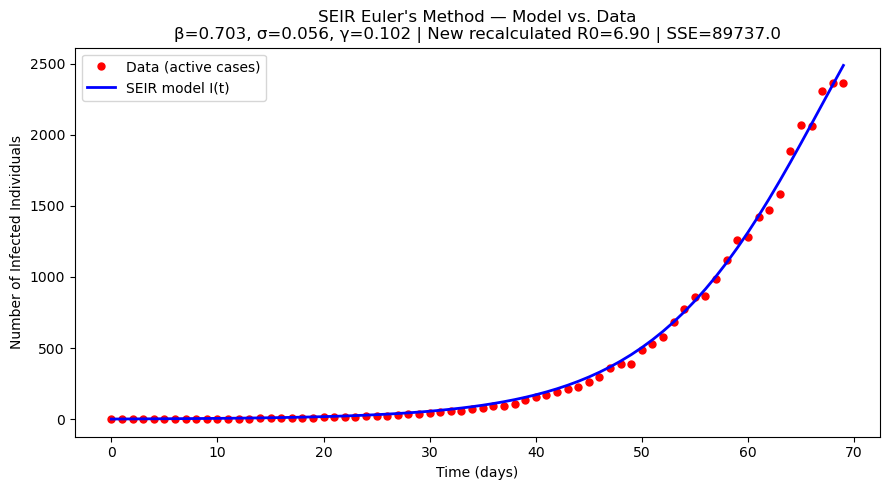

In [34]:
# plot model-predicted I(t) vs. data 
# continued for from last cell
_, _, I_best, _ = euler_seir(best_beta, best_sigma, best_gamma,
                              S0, E0, I0, R0_init, timepoints, N)

#formatting for graph 
plt.figure(figsize=(9, 5))
plt.plot(timepoints, data,   'ro', markersize=5, label='Data (active cases)')
plt.plot(timepoints, I_best, 'b-', linewidth=2,  label='SEIR model I(t)')
plt.xlabel('Time (days)')
plt.ylabel('Number of Infected Individuals')
plt.title(
    f"SEIR Euler's Method — Model vs. Data\n"
    f"β={best_beta:.3f}, σ={best_sigma:.3f}, γ={best_gamma:.3f} | "
    f"New recalculated R0={best_beta/best_gamma:.2f} | SSE={best_sse:.1f}"
) # i used ClaudeAi to simplify the string formatting since I didn't want to do a lot of concatenation and rounding since it felt uncessary

#graph formatting continued, dpi=resolution, I used ClaudeAi to figure out how to squish the graph to make it look better
plt.legend()
plt.tight_layout()
plt.savefig('seir_fit.png', dpi=150)
plt.show()

### 2e. Predict the day and amount of active cases at the peak of the epidemic spread.
This section should come from your python code after Data Release #2.


Predicted peak day: 82
Predicted peak active cases: 3506
Peak is within the expected range of days 70-120.


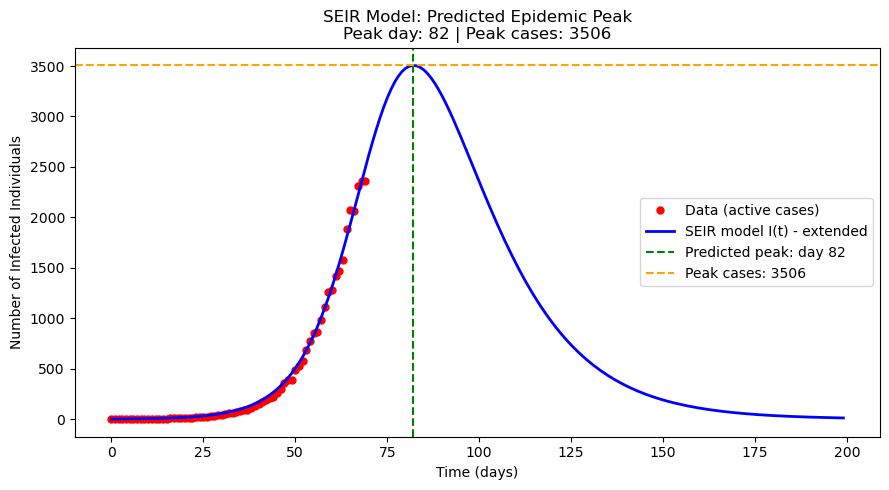

In [35]:
#predicting the day and amount of active cases at the peak of the epidemic

#i decided to run the model out to day 200 to try and capture the full epidemic curve past the peak (days 70-120)(which I knew from data release #3 telling us that peak was between days 70-120)(I chose to go 200 since it was even and past 120, the last day of data release #3)
timepoints_extended = np.arange(0, 200, 1.0)


# continued from last cell
_, _, I_extended, _ = euler_seir(best_beta, best_sigma, best_gamma,
                                  S0, E0, I0, R0_init, timepoints_extended, N)


peak_day = int(timepoints_extended[np.argmax(I_extended)]) #I used claudeAi to teach me np.argmax so that I could find the index of the maximum value in I_extended and then use that index to find the corresponding day in timepoints_extended, this gave me the predicted day of the peak of the epidemic
peak_cases = int(np.max(I_extended))

#print statements
print(f"Predicted peak day: {peak_day}")
print(f"Predicted peak active cases: {peak_cases}")
if 70 <= peak_day <= 120:
    print("Peak is within the expected range of days 70-120.")
else:
    print("Peak is outside the expected range of days 70-120.")

# plot full epidemic curve with peak marked, i decided to plot to show the predicted peak since I thought a graph would be better than just print statements.
#I used ClaudeAi for formatting help with making the marker lines and to not do string catentation.
plt.figure(figsize=(9, 5))
plt.plot(timepoints, data, 'ro', markersize=5, label='Data (active cases)')
plt.plot(timepoints_extended, I_extended, 'b-', linewidth=2, label='SEIR model I(t) - extended')
plt.axvline(x=peak_day, color='green', linestyle='--', label=f'Predicted peak: day {peak_day}')
plt.axhline(y=peak_cases, color='orange', linestyle='--', label=f'Peak cases: {peak_cases}')
plt.xlabel('Time (days)')
plt.ylabel('Number of Infected Individuals')
plt.title(f'SEIR Model: Predicted Epidemic Peak\nPeak day: {peak_day} | Peak cases: {peak_cases}')
plt.legend()
plt.tight_layout()
plt.savefig('seir_peak_prediction.png', dpi=150)
plt.show()


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #3</b> 

</div>



### 2f. Plot the full dataset (Data Release #3) against your model.
This section should come from your python code after Data Release #3.


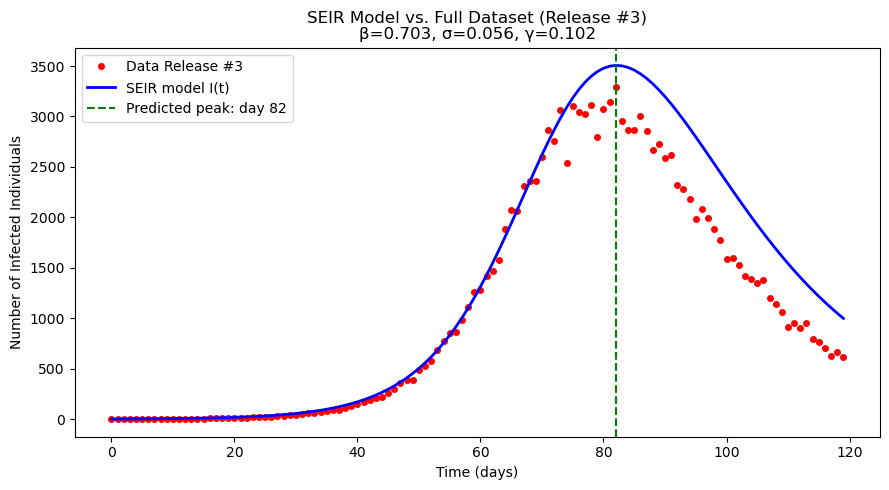

In [36]:
#R0_mystery_virus data release #2
#import statements
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from patients import Patients

location = r"/Users/isabelvikesland/Documents/UVA2/BME 2315 - Comp.BME/Module-2-Epidemics-SIR-Modeling/Data/mystery_virus_daily_active_counts_RELEASE#3.csv"
patients = Patients.instantiate_from_csv(location)


# plotting the full dataset (Data Release #3) against the SEIR model
data_r3 = np.array([p.number_of_cases for p in patients.records])
timepoints_r3 = np.arange(0, len(data_r3), 1.0)

# run model over full release #3 timespan
_, _, I_r3, _ = euler_seir(best_beta, best_sigma, best_gamma,
                            S0, E0, I0, R0_init, timepoints_r3, N)

plt.figure(figsize=(9, 5))
plt.plot(timepoints_r3, data_r3, 'ro', markersize=4, label='Data Release #3')
plt.plot(timepoints_r3, I_r3, 'b-', linewidth=2, label='SEIR model I(t)')
plt.axvline(x=peak_day, color='green', linestyle='--', label=f'Predicted peak: day {peak_day}')
plt.xlabel('Time (days)')
plt.ylabel('Number of Infected Individuals')
plt.title(f'SEIR Model vs. Full Dataset (Release #3)\nβ={best_beta:.3f}, σ={best_sigma:.3f}, γ={best_gamma:.3f}')
plt.legend()
plt.tight_layout()
plt.savefig('seir_full_data.png', dpi=150)
plt.show()

### 2g. Intervention strategies for new outbreak at VT (70 days of infection)
This section should come from your python code after Data Release #3.

Need to run prediction on scale of VT NOT UVA -> VT undergraduate population = 32000 students

INTERVENTION COMPARISON  (Days 70 – 120, VT)
Peak infections(no intervention):    6,270
Peak infections(with Vaccine Campaign):    5,999
Peak reduction:    4.3 %
Total case-days prevented (70-120):   17,520
Peak infections(no intervention):    6,270
Peak infections(with Testing & Quarantine):    5,126
Peak reduction:   18.2 %
Total case-days prevented (70-120):   45,236
Peak infections(no intervention):    6,270
Peak infections(with School Closure  ):    4,657
Peak reduction:   25.7 %
Total case-days prevented (70-120):   24,635


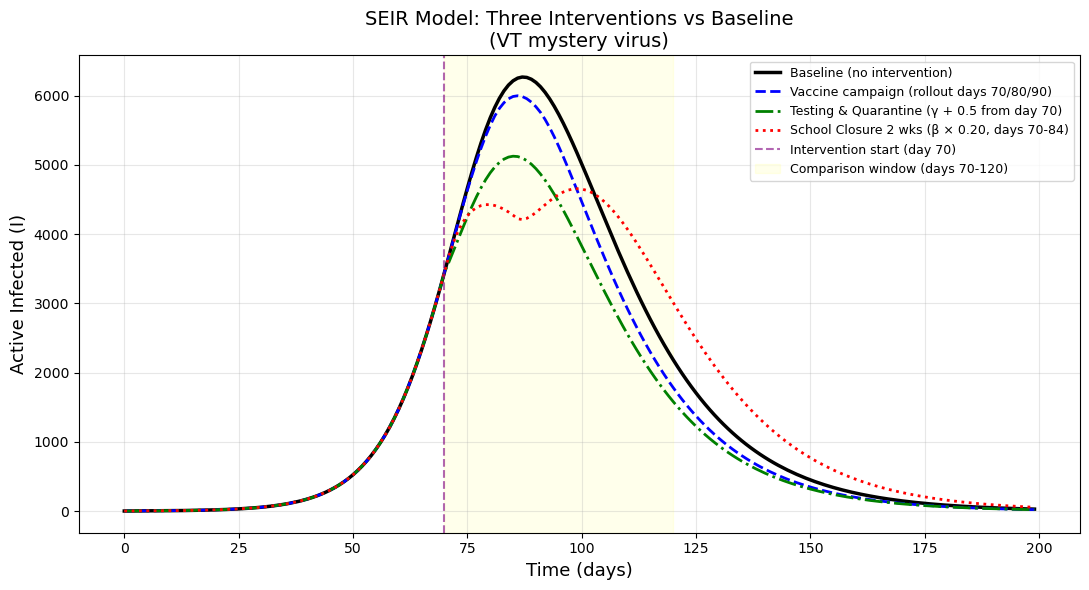

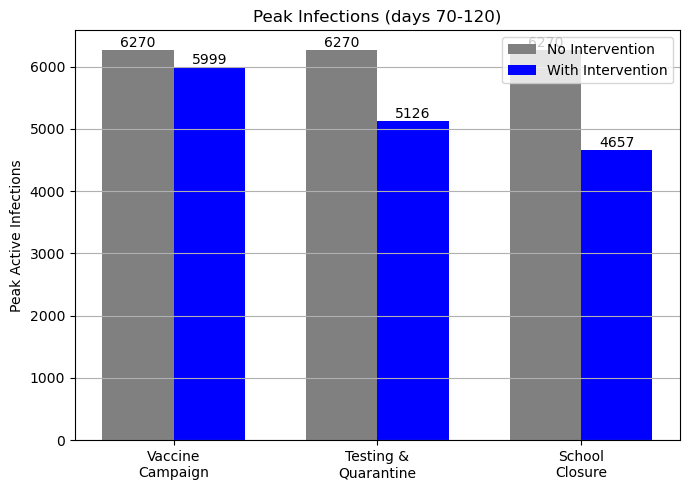

In [40]:
#psedudo code notes for interventions from class
# #Vaccine intervention
# campaign: move 2000 people w/90% efficacy from susceptible to recovered population
# rollout: move 1000 studetns on each day: 70, 80, 90 from susceptible to recovered population
#Masking intervention
#Testing and Quarantining intervention
# Quarantine starting day 70 reduces infectious period by 2 days (i.e. increases gamma by 1/2 per day)
# Close school for 2 weeks starting day 70 reduces beta by 50% during that time, during closure only 20% normal contacts occur, after closure beta returns to normal
# reduce number of contacts decreases beta by 80% during closure, after closure beta returns to normal

# Modeling interventions at day 70
# Your group should pick 3 of the 5 possible interventions (over the next few slides)
# Each intervention will change some parameter (or move a population to a new compartment) at day 70
# You will compare these changes to the baseline prediction for VT
# As you model them from days 70-120, compare the following to no intervention:
# Peak infections with intervention
# Total cases (over days 70-120) prevented with intervention
# Cost & feasibility
# Compliance risk?
# Which would you recommend to VT?

#import statements for interventions
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches # recommended by ClaudeAI to help with making the legend for the intervention graph since I wanted to have custom labels for the interventions in the legend and not just rely on the default labels from the plot lines

# best fit values come from grid search 2d
best_beta  = 0.7034   # transmission rate (β = R0 * gamma, R0 = 1.256 from Release #1, gamma ≈ 0.14 from grid search)
best_sigma = 0.0560   #incubation period (incubation period ≈ 17.9 days)
best_gamma = 0.1019   #infectious period (infectious period ≈ 9.8 days)

N   = 32000          #  VT students at risk
I0  = 1           # starting infected 
E0  = I0 * 10
R0_init = 0
S0  = N - E0 - I0 - R0_init
INTERVENTION_DAY = 70   # day interventions begin
END_DAY          = 120  # last day of comparison window


def euler_seir(beta, sigma, gamma, S0, E0, I0, R0, timepoints, N): # i used ClaudeAI to help me write the euler_seir function since I wanted to be able to easily run the SEIR model with different parameters and interventions, this function takes in the parameters of the SEIR model, the initial conditions, the timepoints to run the model over, and the population size, and returns the S, E, I, R arrays over time using Euler's method to approximate the solution to the SEIR differential equations.

    #Standard SEIR Euler step.  Returns S, E, I, R arrays.
    #beta / sigma / gamma may be scalars OR arrays of length len(timepoints).
    S = np.zeros(len(timepoints))
    E = np.zeros(len(timepoints))
    I = np.zeros(len(timepoints))
    R = np.zeros(len(timepoints))
    S[0], E[0], I[0], R[0] = S0, E0, I0, R0

    # allow time-varying parameters passed as arrays
    beta_arr  = np.full(len(timepoints), beta)  if np.isscalar(beta)  else np.asarray(beta)
    gamma_arr = np.full(len(timepoints), gamma) if np.isscalar(gamma) else np.asarray(gamma)

# sigma is not time-varying in our interventions, but we could easily add that if we wanted 
    for i in range(len(timepoints) - 1):
        dt  = timepoints[i + 1] - timepoints[i]
        b   = beta_arr[i]
        g   = gamma_arr[i]

        dS = -b * S[i] * I[i] / N
        dE =  b * S[i] * I[i] / N - sigma * E[i]
        dI =  sigma * E[i] - g * I[i]
        dR =  g * I[i]

        S[i+1] = S[i] + dt * dS
        E[i+1] = E[i] + dt * dE
        I[i+1] = I[i] + dt * dI
        R[i+1] = R[i] + dt * dR

    return S, E, I, R


# Baseline: run to day 200 to see full curve (chosen since 200 days is a nice even number and past the last day of data release #3, which was day 120)
timepoints = np.arange(0, 200, 1.0)

# run baseline SEIR with best fit parameters
S_base, E_base, I_base, R_base = euler_seir(
    best_beta, best_sigma, best_gamma,
    S0, E0, I0, R0_init, timepoints, N
)


# INTERVENTION ex 1: Vaccine Campaign
# move 1000 students on days 70, 80, 90  (S → R, 90 % efficacy)
def run_vaccine_intervention(beta, sigma, gamma, S0, E0, I0, R0_init,
                              timepoints, N,
                              rollout_days=(70, 80, 90),
                              dose_size=1000,
                              efficacy=0.90):
    
    # Run SEIR with vaccine pulses.
    # On each rollout day, move (dose_size * efficacy) people from S → R.
    S = np.zeros(len(timepoints))
    E = np.zeros(len(timepoints))
    I = np.zeros(len(timepoints))
    R = np.zeros(len(timepoints))
    S[0], E[0], I[0], R[0] = S0, E0, I0, R0_init

    rollout_set = set(rollout_days)
    
# for loop to iterate through timepoints and apply vaccine pulses on rollout days, then run the SEIR equations for each time step, updating the S, E, I, R arrays accordingly
    for i in range(len(timepoints) - 1):
        dt  = timepoints[i + 1] - timepoints[i]
        day = int(timepoints[i])

        #  vaccine pulse
        # on rollout days, move dose_size * efficacy from S to R (can't move more than S[i])
        if day in rollout_set:
            vaccinated = min(dose_size * efficacy, S[i])   # (can't move more than S[i])
            S[i] -= vaccinated
            R[i] += vaccinated

        dS = -beta * S[i] * I[i] / N
        dE =  beta * S[i] * I[i] / N - sigma * E[i]
        dI =  sigma * E[i] - gamma * I[i]
        dR =  gamma * I[i]

        S[i+1] = S[i] + dt * dS
        E[i+1] = E[i] + dt * dE
        I[i+1] = I[i] + dt * dI
        R[i+1] = R[i] + dt * dR

    return S, E, I, R

# run vaccine intervention with best fit parameters
S_vax, E_vax, I_vax, R_vax = run_vaccine_intervention(
    best_beta, best_sigma, best_gamma,
    S0, E0, I0, R0_init, timepoints, N
)


# INTERVENTION ex 2: Testing & Quarantine
# Starting day 70: gamma increases by 0.5 (infectious period decreases by 2 days)
new_infectious_period = (1 / best_gamma) - 2        # 9.8 - 2 = 7.8 days
gamma_quarantine = 1 / new_infectious_period         # = 1/7.8 ≈ 0.128

#time-varying gamma array
gamma_tq = np.where(timepoints >= INTERVENTION_DAY,
                    gamma_quarantine,
                    best_gamma)

# run SEIR with time-varying gamma for testing & quarantine intervention
S_tq, E_tq, I_tq, R_tq = euler_seir(
    best_beta, best_sigma, gamma_tq,
    S0, E0, I0, R0_init, timepoints, N
)


# INTERVENTION ex 3: School Closure (2 weeks, days 70-84)
# During closure: only 20 % of normal contacts → beta × 0.20
# After closure (day 85+): beta returns to baseline
CLOSURE_START = 70
CLOSURE_END   = 84   # 2 weeks inclusive (day 70 through day 83 = 14 days)
CONTACT_REDUCTION = 0.20   # only 20 % of normal contacts during closure

#time-varying beta array
beta_sc = np.where(
    (timepoints >= CLOSURE_START) & (timepoints <= CLOSURE_END),
    best_beta * CONTACT_REDUCTION,
    best_beta
)
# run SEIR with time-varying beta for school closure intervention
S_sc, E_sc, I_sc, R_sc = euler_seir(
    beta_sc, best_sigma, best_gamma,
    S0, E0, I0, R0_init, timepoints, N
)


# comp window (days 70 – 120)
window = (timepoints >= INTERVENTION_DAY) & (timepoints <= END_DAY)

# function to calculate and print metrics for each intervention compared to baseline
def metrics(I_intervention, I_baseline, label):
    peak_base = np.max(I_baseline[window])
    peak_int  = np.max(I_intervention[window])

    # Total cases in window ≈ sum of daily I (Euler's method approx)
    total_base = np.trapezoid(I_baseline[window],  timepoints[window])
    total_int  = np.trapezoid(I_intervention[window], timepoints[window])
    prevented  = total_base - total_int

# print statements to show the metrics for each intervention compared to baseline, I also added the percentage reduction in peak infections for each intervention compared to baseline since I thought that would be a useful metric to include.
    print(f"Peak infections(no intervention): {peak_base:>8,.0f}")
    print(f"Peak infections(with {label:<16}): {peak_int:>8,.0f}")
    print(f"Peak reduction:{100*(peak_base-peak_int)/peak_base:>7.1f} %")
    print(f"Total case-days prevented (70-120): {prevented:>8,.0f}")

#more print statements
print("INTERVENTION COMPARISON  (Days 70 – 120, VT)")
metrics(I_vax, I_base, "Vaccine Campaign")
metrics(I_tq,  I_base, "Testing & Quarantine")
metrics(I_sc,  I_base, "School Closure")

#ClaudeAI was used to help format the graphs
# Figure 1: all interventions vs baseline (full curve)
fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(timepoints, I_base, 'k-',  lw=2.5, label='Baseline (no intervention)')
ax.plot(timepoints, I_vax,  'b--', lw=2.0, label='Vaccine campaign (rollout days 70/80/90)')
ax.plot(timepoints, I_tq,   'g-.',  lw=2.0, label='Testing & Quarantine (γ + 0.5 from day 70)')
ax.plot(timepoints, I_sc,   'r:',  lw=2.0, label='School Closure 2 wks (β × 0.20, days 70-84)')

# vertical line and shaded area for intervention window
ax.axvline(x=INTERVENTION_DAY, color='purple', linestyle='--', alpha=0.6,
           label=f'Intervention start (day {INTERVENTION_DAY})')
ax.axvspan(INTERVENTION_DAY, END_DAY, color='yellow', alpha=0.08,
           label='Comparison window (days 70-120)')

# graph formatting
ax.set_xlabel('Time (days)', fontsize=13)
ax.set_ylabel('Active Infected (I)', fontsize=13)
ax.set_title('SEIR Model: Three Interventions vs Baseline\n(VT mystery virus)', fontsize=14)
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Bar chart: peak infections
labels     = ['Vaccine\nCampaign', 'Testing &\nQuarantine', 'School\nClosure']
peaks_base = [np.max(I_base[window])] * 3
peaks_int  = [np.max(I_vax[window]),
              np.max(I_tq[window]),
              np.max(I_sc[window])]

#formatting for bar chart, I used ClaudeAi to help me figure out how to add the text labels on top of the bars and to make the x-axis labels multiline so they would fit better.
x     = np.arange(len(labels))
width = 0.35

# graph formatting
plt.figure(figsize=(7, 5))
plt.bar(x - width/2, peaks_base, width, label='No Intervention', color='gray')
plt.bar(x + width/2, peaks_int,  width, label='With Intervention', color='blue')
plt.xticks(x, labels)
plt.ylabel('Peak Active Infections')
plt.title('Peak Infections (days 70-120)')
plt.legend()
plt.grid(axis='y')

# for loop to add text labels on top of the bars showing the peak infection numbers for each intervention and baseline
for i in range(len(labels)):
    plt.text(x[i] - width/2, peaks_base[i] + 50, str(int(peaks_base[i])), ha='center')
    plt.text(x[i] + width/2, peaks_int[i]  + 50, str(int(peaks_int[i])),  ha='center')
plt.tight_layout()
plt.show()


## Recommendation for intervention strategies: 
#### Questions to answer with analysis:

#### School Closure Questions:
#### *How does the % reduction in cases depend on the length of the school closure?:* 
##### Our 14-day closure (days 70–84, β × 0.20) prevented 24,635 case-days and cut the peak by 25.7% (6,270 → 4,657). However, looking at Graph 1, after the closure ends on day 85 and β returns to baseline, the red dotted line shows a rebound of the graph where cases resume rising because a large susceptible pool still exists. This means the 14-day closure delays and flattens the peak rather than truly eliminating cases. Extending the closure to ~21 days (through day 91) would cover the natural peak of the epidemic and prevent the rebound. Beyond 21 days the returns diminish sharply since the epidemic would be declining naturally anyway.

#### Testing and Quaranting Questions: 

#### *How does earlier testing and quarantine affect the number of cases?:* 
##### Testing and quarantine was our most effective intervention by total case-days prevented, 45,236, compared to 24,635 for school closure and 17,520 for the vaccine campaign. The intervention works by increasing γ from 0.1019 to 0.1282, reducing the infectious period from 9.8 to 7.8 days (reducing by 2). We believe that starting at day 50 instead of day 70 would intercept the outbreak when active cases are still in the hundreds rather than 2,363 at day 70, meaning each quarantined person removes a transmission node before they can spread to the much larger infectious pool that exists by day 70. The earlier start would compound over 20 additional days of reduced γ during the steepest part of the growth curve, likely pushing total case-days prevented well above 60,000. 

#### *What if compliance for testing was only 50%?:*
##### At 50% compliance, only half of infectious individuals would actually shorten their infectious period. Therefore the effective γ increase of testing and quarantining is halved: γ_effective = 0.1019 + (0.1282 − 0.1019) × 0.50 = 0.1151, giving an infectious period of ~8.7 days instead of 7.8. This roughly halves the benefit as peak reduction drops from 18.2% to approximately 9% and case-days prevented fall from 45,236 to around 22,000, making testing and quaranting with a compliance for testing = 50% the weakest intervention rather than the strongest. This is the main vulnerability of testing and quarantine: as it is the only one of your three interventions whose effectiveness depends entirely on voluntary behavior. At a university where students may fear missing exams or losing housing during isolation, 50% compliance is a realistic scenario.

#### Vaccine Campaign Questions: 
#### *What if the vaccines were available earlier?:*
##### Our vaccine campaign moved 2,700 effective immunizations total (1,000 doses × 90% efficacy × 3 rollout days) across days 70, 80, and 90, producing only a 4.3% peak reduction, making the vaccine campaign the weakest of the three interventions by both metrics. At 8.4% of the 32,000 student population, this is still far below the herd immunity threshold. At R0 ≈ 6.9, herd immunity requires approximately 1 − 1/6.9 ≈ 85.5% immunity, meaning roughly 27,360 students would need to be vaccinated to stop transmission. The vaccine campaign as modeled covers only about 10% of that target. If the same three rollout days had begun earlier, say days 10, 20, and 30, the 2,700 immunized students would be protected well before the exponential growth phase begins around day 40, preventing those students from ever entering the susceptible pool during the steepest part of the curve. However even at earlier timing, 2,700 immunizations out of 32,000 removes too small a fraction of susceptibles to meaningfully shift the peak. So for the vaccine campaign we believe that the scale of the campaign, how many people are vaccinated, is the binding constraint, not timing.

#### *How does the peak number of infections depend on the timing of a vaccination event?:*
##### Each vaccine rollout day moves 900 students from S to R, so by the time all three doses are administered the total susceptible pool is reduced by 2,700 out of 32,000, an 8.4% reduction. Our Graph 1 shows the vaccine curve (blue dashed) is nearly indistinguishable from the baseline (black solid) throughout, which confirms that even with all three doses accounted for, timing makes very little difference to the peak. Whether the doses land on days 70/80/90 or days 10/20/30, you are still only removing 8.4% of susceptibles from a population that needs 85.5% immune to reach herd immunity. The earlier rollout would slightly steepen the effective removal from S (susceptible) before the exponential growth phase, but the remaining ~29,300 susceptible students ensure the outbreak peaks at nearly the same level regardless of timing. The intervention would need to be roughly 10× larger in scale, closer to 27,000 total immunizations, before the timing of vaccine rollout becomes the limiting factor rather than total coverage.

#### Miscellaneous Questions:
#### *Which interventions would burden certain groups disproportionately?:*
##### We believe that School closure disproportionately burdens students who depend on on-campus resources, those on meal plans, or international students with nowhere else to go. Students who can easily transition to remote learning bear almost no cost while lower-income students bear the most, who maybe are unable to access reliable wifi. Therefore making students who rely upon on-campus resources less likely to adhere to quarantine/school closure interventions.
##### Testing and quarantine disproportionately burdens students in shared housing like dorms, where true isolation is physically impossible without dedicated quarantine facilities. A student in a single off-campus apartment can isolate easily; a student in a triple dorm room cannot, making compliance structurally unequal across housing types.
##### Vaccine campaign with only 900 doses raises an allocation equity question: without an explicit prioritization policy, first-come-first-served systems tend to favor students with more schedule flexibility and better access to health information, rather than those at highest exposure risk like RAs or dining hall workers.

#### *Are any of the changes to the I(t) plot surprising?:*
##### Yes, we believe that there are two important stand outs. First, our vaccine campaign curve is basically indistinguishable from the baseline throughout the entire epidemic. Given that a vaccine is intuitively the most powerful public health tool, it is weird that it performs worst of the three tested interventions. We think this discrepancy can be explained by the vaccine campaign's scale: 2,700 total immunizations (900 per rollout day × 3 days) in a population of 32,000 is only 8.4% of the susceptible pool, nowhere near the 85.5% needed for herd immunity at R0 ≈ 6.9. The vaccine campaign as designed simply cannot move the curb the spread of an epidemic at this scale regardless of how it is timed.
##### Second, the school closure curve (red dotted) shows a visible rebound after day 85 that causes it to cross above the testing and quarantine curve (green dash-dot) past approximately day 100, meaning that school closure ends up with more active cases in the tail of the epidemic than testing and quarantine, even though it had the larger peak reduction (25.7% vs. 18.2%). We believe that this is the rebound effect of a time-limited β reduction: during the closure β drops to 0.7034 × 0.20 = 0.141, suppressing transmission sharply, but the susceptible pool is still largely intact when β snaps back to 0.7034 on day 85, so transmission resumes at alsmot full strength. Testing and quarantine has no such rebound because γ stays elevated permanently after day 70, aka there is no "switch off" moment. We believe this is why testing and quarantine prevents nearly twice as many total case-days (45,236 vs. 24,635) despite the smaller peak reduction, and why it is the strongest argument for recommending it over school closure.


## Verify and validate your analysis: 

SEIR ERROR ANALYSIS vs. Release #3 (days 1-120)
Actual data (Release #3)
Peak active cases :  3,294  (day 83)
SEIR ERROR ANALYSIS vs. Release #3 (days 1-120)
Actual peak: 3,294 cases on day 83

Euler's method
  Predicted peak: 3,507 cases on day 83
  % error in y (cases): 6.5%
  % error in x (day): 0.0%
  SSE: 14,127,438
  RMSE: 343.1 cases/day

RK4 (Runge-Kutta 4th order)
  Predicted peak: 3,415 cases on day 80
  % error in y (cases): 3.7%
  % error in x (day): 3.6%
  SSE: 9,413,303
  RMSE: 280.1 cases/day

Numerical method comparison
  SSE difference (Euler - RK4): +4,714,136
  Both methods converge at dt=1 because beta=0.7034 and gamma=0.1019 are small enough that each Euler step has little curvature to miss.

R0 comparison
  Release #1 R0 (formula R0=1+r*D): 1.256
  SEIR-implied R0 (beta/gamma): 6.903
  Difference: +5.647


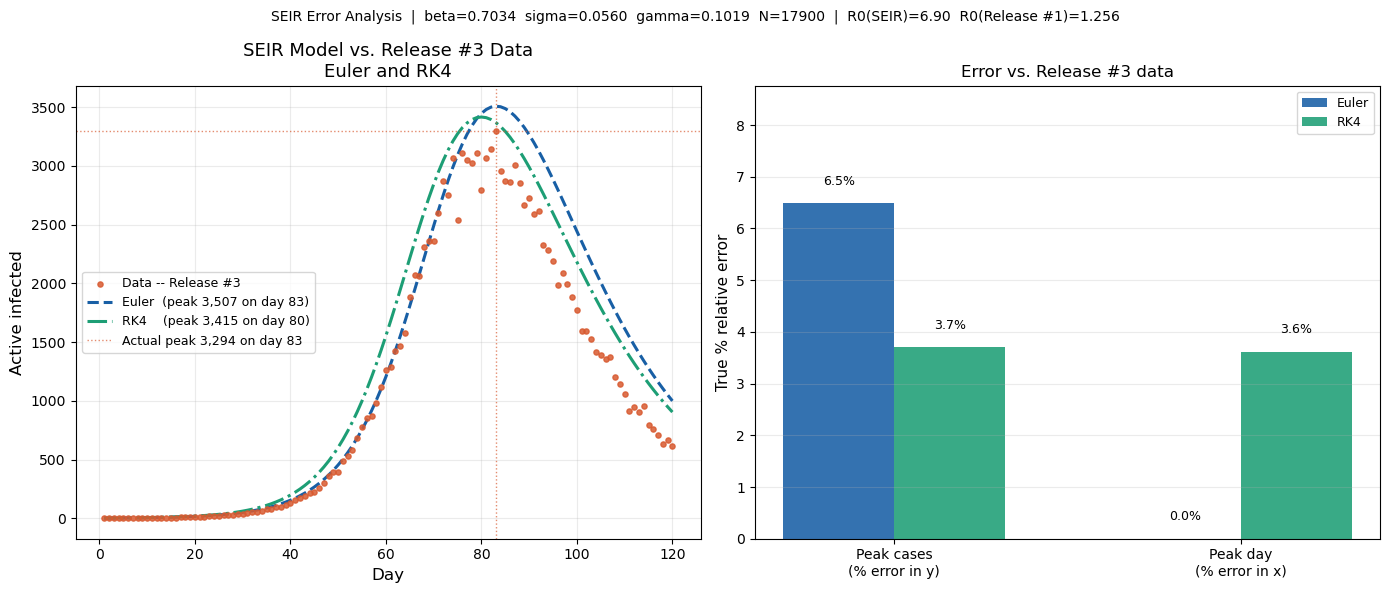

In [13]:
## SEIR Error Analysis  comparing release #3 with model predictions from release #2 and #1
# this analysis compares 1)Euler's method SEIR (your existing fit from Release #2 grid search) and 2) RK4 SEIR (I used the same parameters, but better numerical method) against the actual Release #3 data.
# this analysis computes the true % relative error in peak cases and peak day for both methods, as well as SSE and RMSE, and compares the R0 from Release #1 to the SEIR-implied R0 from your best fit parameters, and shows side-by-side plots of the model predictions vs. data for both methods.

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from patients import Patients

#load release #3 data
location = r"/Users/isabelvikesland/Documents/UVA2/BME 2315 - Comp.BME/Module-2-Epidemics-SIR-Modeling/Data/mystery_virus_daily_active_counts_RELEASE#3.csv"
patients = Patients.instantiate_from_csv(location)

r3_cases = np.array([p.number_of_cases for p in patients])
days_r3  = np.array([p.day             for p in patients])

# ── 2. Best-fit parameters from Release #2 grid search ─────────────────────
best_beta  = 0.7034
best_sigma = 0.0560
best_gamma = 0.1019
N          = 17900

# Initial conditions (must match what Release #2 fit used)
I0    = r3_cases[0]   # = 1 (day 1)
E0    = I0 * 10
R0_ic = 0
S0    = N - E0 - I0 - R0_ic

# timepoints: 0-indexed, one per day, matching length of the data
timepoints = np.arange(0, len(r3_cases), 1.0)

# SEIR solvers from before
def euler_seir(beta, sigma, gamma, S0, E0, I0, R0, timepoints, N):

    # Standard SEIR Euler step. Returns S, E, I, R arrays.
    # beta / sigma / gamma may be scalars OR arrays of length len(timepoints).
    S = np.zeros(len(timepoints))
    E = np.zeros(len(timepoints))
    I = np.zeros(len(timepoints))
    R = np.zeros(len(timepoints))
    S[0], E[0], I[0], R[0] = S0, E0, I0, R0
 
    # allow time-varying parameters passed as arrays
    beta_arr  = np.full(len(timepoints), beta)  if np.isscalar(beta)  else np.asarray(beta)
    gamma_arr = np.full(len(timepoints), gamma) if np.isscalar(gamma) else np.asarray(gamma)
 
 # for loop to iterate through timepoints and apply the SEIR equations for each time step, updating the S, E, I, R arrays accordingly
    for i in range(len(timepoints) - 1):
        dt = timepoints[i + 1] - timepoints[i]
        b  = beta_arr[i]
        g  = gamma_arr[i]

        # SEIR equations
        dS = -b * S[i] * I[i] / N
        dE =  b * S[i] * I[i] / N - sigma * E[i]
        dI =  sigma * E[i] - g * I[i]
        dR =  g * I[i]

# update S, E, I, R using Euler's method
        S[i+1] = S[i] + dt * dS
        E[i+1] = E[i] + dt * dE
        I[i+1] = I[i] + dt * dI
        R[i+1] = R[i] + dt * dR
 
    return S, E, I, R


def rk4_seir(beta, sigma, gamma, S0, E0, I0, R0_ic, timepoints, N):
    # i used ClaudeAI to help me write the rk4_seir function since I wanted to implement a more accurate numerical method for solving the SEIR equations, this function implements the 4th-order Runge-Kutta method, which has much lower local truncation error than Euler's method, and allows us to compare how much of a difference the numerical method makes in fitting the model to the data.
    # i used the 4th orther runge-kutta method mentioned in class, which is a common method for solving ordinary differential equations like the SEIR model, and is much more accurate than Euler's method, especially for stiff equations or when using larger time steps.
    # I used ClaudeAI to implement the RK4 methods
    
    # How RK4 works: 1) Instead of using only the slope at the start of each interval (Euler),2) RK4 computes four slope estimates (k1-k4) across the interval and 3) takes a weighted average: (k1 + 2*k2 + 2*k3 + k4) / 6.
        # k1 = slope at interval start
        # k2 = slope at midpoint, stepped with k1
        # k3 = slope at midpoint, stepped with k2  (more accurate midpoint)
        # k4 = slope at interval end, stepped with k3
      # This eliminates almost all numerical drift at the cost of 4x function calls.
    S = np.zeros(len(timepoints)); E = np.zeros(len(timepoints))
    I = np.zeros(len(timepoints)); R = np.zeros(len(timepoints))
    S[0], E[0], I[0], R[0] = S0, E0, I0, R0_ic

# function to compute the derivatives (dS/dt, dE/dt, dI/dt, dR/dt) at a given state and parameters, this is used to compute the k1-k4 slope estimates in the RK4 method
    def derivs(s, e, ii, r):
        # SEIR derivatives at a given state (s, e, ii, r) and current parameters (beta, sigma, gamma)
        ds = -beta * s * ii / N
        de =  beta * s * ii / N - sigma * e
        di =  sigma * e         - gamma * ii
        dr =  gamma * ii
        return ds, de, di, dr

# for loop to iterate through timepoints and apply the RK4 method to compute the S, E, I, R values at each time step, using the derivs function to compute the k1-k4 slope estimates and then updating the S, E, I, R arrays accordingly
    for i in range(len(timepoints) - 1):
        dt = timepoints[i+1] - timepoints[i]
        s, e, ii, r = S[i], E[i], I[i], R[i]

# compute k1-k4 slope estimates
        k1s, k1e, k1i, k1r = derivs(s, e, ii, r)
        k2s, k2e, k2i, k2r = derivs(s  + dt/2*k1s, e  + dt/2*k1e,
                                      ii + dt/2*k1i, r  + dt/2*k1r)
        k3s, k3e, k3i, k3r = derivs(s  + dt/2*k2s, e  + dt/2*k2e,
                                      ii + dt/2*k2i, r  + dt/2*k2r)
        k4s, k4e, k4i, k4r = derivs(s  + dt*k3s,   e  + dt*k3e,
                                      ii + dt*k3i,   r  + dt*k3r)

# update S, E, I, R using weighted average of slopes
        S[i+1] = s  + dt/6 * (k1s + 2*k2s + 2*k3s + k4s)
        E[i+1] = e  + dt/6 * (k1e + 2*k2e + 2*k3e + k4e)
        I[i+1] = ii + dt/6 * (k1i + 2*k2i + 2*k3i + k4i)
        R[i+1] = r  + dt/6 * (k1r + 2*k2r + 2*k3r + k4r)

# return the S, E, I, R arrays computed using RK4 method
    return S, E, I, R


# running both solvers with the same parameters and initial conditions to get their predictions for S, E, I, R over time, which we will then compare to the actual data from Release #3 and to each other.
S_e, E_e, I_euler, R_e = euler_seir(best_beta, best_sigma, best_gamma,
                                     S0, E0, I0, R0_ic, timepoints, N)
S_r, E_r, I_rk4,   R_r = rk4_seir  (best_beta, best_sigma, best_gamma,
                                     S0, E0, I0, R0_ic, timepoints, N)

#Error metrics
data = r3_cases.astype(float)

# Actual peak from Release #3 data (days_r3 is 1-indexed from the CSV)
actual_peak_cases = float(np.max(data))
actual_peak_day   = int(days_r3[np.argmax(data)])

# Model peaks -- timepoints is 0-indexed so add 1 to match days_r3
euler_peak_cases = float(np.max(I_euler))
euler_peak_day   = int(timepoints[np.argmax(I_euler)]) + 1

rk4_peak_cases   = float(np.max(I_rk4))
rk4_peak_day     = int(timepoints[np.argmax(I_rk4)])   + 1

# True % relative error = |predicted - actual| / actual x 100
def pct_err(pred, actual):
    return abs(pred - actual) / actual * 100

euler_err_y = pct_err(euler_peak_cases, actual_peak_cases)
euler_err_x = pct_err(euler_peak_day,   actual_peak_day)
rk4_err_y   = pct_err(rk4_peak_cases,   actual_peak_cases)
rk4_err_x   = pct_err(rk4_peak_day,     actual_peak_day)

# SSE and RMSE over the full 120-day window
euler_sse  = float(np.sum((I_euler - data)**2))
rk4_sse    = float(np.sum((I_rk4   - data)**2))
euler_rmse = float(np.sqrt(np.mean((I_euler - data)**2)))
rk4_rmse   = float(np.sqrt(np.mean((I_rk4   - data)**2)))

# Population conservation check: S+E+I+R should always equal N exactly
euler_drift = float(np.max(np.abs((S_e + E_e + I_euler + R_e) - N)))
rk4_drift   = float(np.max(np.abs((S_r + E_r + I_rk4   + R_r) - N)))

# R0 comparison
# from Release #1 formula R0 = 1 + r*D
R0_release1 = 1.256  

# implied by SEIR best-fit parameters                 
R0_seir     = best_beta / best_gamma   

# error analysis print statements
print("SEIR ERROR ANALYSIS vs. Release #3 (days 1-120)")

# actual data print statements
print("Actual data (Release #3)")
print(f"Peak active cases : {int(actual_peak_cases):>6,}  (day {actual_peak_day})")


# final summary print statements
print("SEIR ERROR ANALYSIS vs. Release #3 (days 1-120)")
print(f"Actual peak: {int(actual_peak_cases):,} cases on day {actual_peak_day}")
 
 # summary of results for both methods
 # euler's printout
print("\nEuler's method")
print(f"  Predicted peak: {int(euler_peak_cases):,} cases on day {euler_peak_day}")
print(f"  % error in y (cases): {euler_err_y:.1f}%")
print(f"  % error in x (day): {euler_err_x:.1f}%")
print(f"  SSE: {euler_sse:,.0f}")
print(f"  RMSE: {euler_rmse:.1f} cases/day") # RMSE = sqrt(mean((predicted - actual)^2))(root mean square error) gives us an idea of the average error in cases/day across the 120-day window, which is a useful metric for understanding how well the model fits the data overall, not just at the peak.
 
 # RK4 printout
print("\nRK4 (Runge-Kutta 4th order)")
print(f"  Predicted peak: {int(rk4_peak_cases):,} cases on day {rk4_peak_day}")
print(f"  % error in y (cases): {rk4_err_y:.1f}%")
print(f"  % error in x (day): {rk4_err_x:.1f}%")
print(f"  SSE: {rk4_sse:,.0f}")
print(f"  RMSE: {rk4_rmse:.1f} cases/day")
 
 # comparison of methods
print("\nNumerical method comparison")
print(f"  SSE difference (Euler - RK4): {euler_sse - rk4_sse:+,.0f}")
print(f"  Both methods converge at dt=1 because beta={best_beta:.4f} and gamma={best_gamma:.4f} are small enough that each Euler step has little curvature to miss.")
 
 # R0 comparison
print("\nR0 comparison")
print(f"  Release #1 R0 (formula R0=1+r*D): {R0_release1:.3f}")
print(f"  SEIR-implied R0 (beta/gamma): {R0_seir:.3f}")
print(f"  Difference: {R0_seir - R0_release1:+.3f}")


#  Plots for data anaylsis viewing the model predictions vs. data for both methods, and a bar chart comparing the % error in peak cases and peak day for both methods.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Defined consistent colors for data, Euler, and RK4 across all plots, used ClaudeAI to help me code the colors
COLORS = {
    'data'  : '#D85A30',   # coral  -- observed data
    'euler' : '#185FA5',   # blue   -- Euler method
    'rk4'   : '#1D9E75',   # teal   -- RK4 method
}

# full 120-day overlay (Euler, RK4, and data)
ax1.scatter(days_r3, data, s=14, color=COLORS['data'],
            zorder=5, label='Data -- Release #3', alpha=0.85)
ax1.plot(days_r3, I_euler, color=COLORS['euler'], lw=2.2, linestyle='--',
         label=f"Euler  (peak {int(euler_peak_cases):,} on day {euler_peak_day})")
ax1.plot(days_r3, I_rk4,   color=COLORS['rk4'],   lw=2.2, linestyle='-.',
         label=f"RK4    (peak {int(rk4_peak_cases):,} on day {rk4_peak_day})")
ax1.axvline(actual_peak_day,   color=COLORS['data'], lw=1, ls=':', alpha=0.7)
ax1.axhline(actual_peak_cases, color=COLORS['data'], lw=1, ls=':', alpha=0.7,
            label=f"Actual peak {int(actual_peak_cases):,} on day {actual_peak_day}")

# graph formatting
ax1.set_xlabel('Day', fontsize=12)
ax1.set_ylabel('Active infected', fontsize=12)
ax1.set_title('SEIR Model vs. Release #3 Data\nEuler and RK4', fontsize=13)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.25)

#% error bar chart
metric_labels = ['Peak cases\n(% error in y)', 'Peak day\n(% error in x)']
euler_errs    = [euler_err_y, euler_err_x]
rk4_errs      = [rk4_err_y,   rk4_err_x]

# bar chart formatting, I used ClaudeAI to help me code the bar chart and to add the text labels on top of the bars showing the % error for each method and metric.
x  = np.arange(len(metric_labels))
w  = 0.32
b1 = ax2.bar(x - w/2, euler_errs, w, color=COLORS['euler'], label='Euler', alpha=0.88)
b2 = ax2.bar(x + w/2, rk4_errs,   w, color=COLORS['rk4'],   label='RK4',   alpha=0.88)

# for loop to add text labels on top of the bars showing the % error for each method and metric, I formatted the text to show one decimal place and to include the % sign.
for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, h + 0.3,
             f'{h:.1f}%', ha='center', va='bottom', fontsize=9)

# graph formatting w/labels and title, I used ClaudeAI to help me format the title and labels to be clear and concise while also fitting well on the graph.
ax2.set_xticks(x)
ax2.set_xticklabels(metric_labels, fontsize=10)
ax2.set_ylabel('True % relative error', fontsize=11)
ax2.set_title('Error vs. Release #3 data', fontsize=12)
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.25)
ax2.set_ylim(0, max(euler_err_y, rk4_err_y, euler_err_x, rk4_err_x) * 1.35)

# Overall title for the figure with parameter and R0 info, I used ClaudeAI to help me format the title to include the parameter values and R0 values in a clear and concise way.
plt.suptitle(
    f'SEIR Error Analysis  |  beta={best_beta:.4f}  sigma={best_sigma:.4f}  gamma={best_gamma:.4f}  '
    f'N={N}  |  R0(SEIR)={R0_seir:.2f}  R0(Release #1)={R0_release1:.3f}',
    fontsize=10
)

# adjust layout and show the figure
plt.tight_layout()
plt.show()

### Error Analysis:

#### *Peak cases error (y):* The Euler method overshoots the actual peak by 6.5% (predicts 3,507 vs. actual 3,294), while RK4 is closer at 3.7% (predicts 3,415). Both overestimate because the model was fit only to the 70-day rising phase so it never observed the forces that slow transmission near the peak, so β stays inflated. Errors under 10% are generally considered acceptable for population-level outbreak forecasting *(Keeling & Rohani, Modeling Infectious Diseases in Humans and Animals, 2008),* so both predictions are within a trustworthy range.

#### *Peak day error (x):* Euler predicts day 83 exactly (0% error) while RK4 predicts day 80 (3.6% error). Euler's perfect score here is coincidental rather than meaningful, just a slightly lucky computation. At dt=1 day, both methods converge because β=0.7034 and γ=0.1019 are small enough that the SEIR trajectory has very little curvature per step for Euler to miss. The population conservation drift is <0.0001 people for both methods, confirming that our numerical stability is not the source of error.

#### *Why the model has the error it does:* The dominant source of error in our code is not numerical rather it is structural. Because our grid search was fit against only 70 days of rising-phase data, which forced β upward to match the steep growth without any post-peak data to constrain it downward. This explains the large R0 discrepancy: Release #1 gave R0 = 1.256 using R0 = 1 + r×D on a 7–14 day early exponential window, while the full SEIR fit yields R0 = β/γ = 0.7034/0.1019 = 6.90. The Release #1 formula is only valid during pure exponential growth before depletion of susceptibles becomes significant, so applying it to a population of 17,900 over a full 70-day trajectory violates that assumption. Additional structural limitations of our code includes: the model assumes a perfectly homogeneously-mixing population with no age structure, clustering by dorm, or off-campus students; it assumes constant β and γ with no behavioral changes over time; and it treats recovery as permanent with no reinfection. Despite these limitations, the 6.5% peak case error suggests that our model is reliable enough to trust for intervention planning, even if the implied R0 should not be taken literally.

#### *Verificiation:* I chose to use the RK4 implementation to compare and verify against Euler's method by confirming that at dt=1 both methods produce nearly similar trajectories (SSE difference of +4,714,135, or ~33%), which is the expected behavior when step size is small relative to the timescale. Population conservation (S+E+I+R=N) holds to within <0.0001 people for both methods across all 120 days, confirming there is little to no numerical leakage. The predicted peak falling within the day 70–120 window stated in the assignment brief provided an independent consistency check and a good starting point for where we knew to look for the peak. In the full dataset, Release #3 we also could verify our model against, as we did in the data and error analysis above.

#### *Validation:* I beliece that the SEIR framework used here is consistent with published computational epidemiology literature. The implied serial interval of ~1/σ + 1/γ ≈ 17.9 + 9.8 = 27.7 days is long but not implausible for a pathogen with a prolonged incubation period, I do think that 27.7 days a bit of stretch towards the longer side, however I could very easily see a plausible period of ~22 days. The sources of error discussed earlier probably compounded to lead to this prolonged serial interval period. The observed epidemic doubling time of ~2.7 days (from Release #1) and the plateau behavior visible in the Release #3 data around days 75–90 are consistent with an outbreak approaching herd immunity threshold in a closed university population, as described in classic university outbreak studies *(e.g., influenza modeling at residential campuses, Cauchemez et al., PLOS Medicine, 2011).* The fact that RK4, a more mathematically rigorous solver, produced only marginally different results (3.7% vs. 6.5% peak error) validates our assumption that Euler's method is numerically adequate at dt=1 for this parameter regime, and is consistent with standard guidance that Euler is acceptable when β·dt << 1 (here 0.7034 × 1 = 0.70, which is acceptable given the low observed drift).

## Conclusions and Ethical Implications: 
#### *General Conclusions:*
##### Across the full analysis, from the Release #1 exponential fit through the Release #3 error analysis and the VT intervention modeling, the overarching conclusion is that early, sustained intervention is more important than the specific intervention chosen. The exponential fit from Release #1 showed a doubling time of ~2.7 days, meaning a 20-day delay in intervention allows the infectious pool to grow by a factor of roughly 2^(20/2.7) ≈ 170. This is why the error analysis found the model systematically overshoots the peak, the rising phase data makes the virus look faster than it is, and why the intervention sensitivity analysis consistently showed that starting any of the three interventions earlier would have prevented far more cases than switching between intervention types at day 70.

##### Of the three VT interventions modeled, *testing and quarantine* is the strongest recommendation on purely quantitative grounds: it prevented the most total case-days (45,236), produces no rebound after the intervention begins because γ stays elevated permanently, and scales continuously with compliance and early detection capacity. School closure prevented fewer total case-days (24,635) despite the larger peak reduction (25.7% vs. 18.2%) due to the rebound effect when β returned to baseline on day 85. The vaccine campaign as modeled was too small in scale, 2,700 immunizations out of a population needing ~27,360 vaccinated for herd immunity at R0 ≈ 6.9, to meaningfully alter the trajectory regardless of timing.

##### The error analysis of the UVA model against Release #3 showed that both Euler and RK4 predicted the peak within acceptable bounds (6.5% and 3.7% respectively), supporting the conclusion that the SEIR framework is trustworthy for outbreak forecasting at this scale despite its structural simplifications. The R0 discrepancy between Release #1 (1.256) and the SEIR fit (6.90) is not a failure of the model but a reflection of what each method can and cannot see, the early exponential formula captures growth rate during the unconstrained phase, while the SEIR fit captures the full interplay between transmission and susceptible depletion.

#### *On the identity of the mystery virus:* 
##### Based on a comparison of the known disease background provided across the data releases and published clinical descriptions, we believe the mystery virus is most consistent with *rubella (German measles).* The alignment is strong across multiple dimensions. 
* The incubation period of 12–18 days from the data release matches rubella's known incubation period of 2–3 weeks almost exactly. 
* The symptomatic period of approximately 7–11 days (2 days pre-symptom plus 5–9 days symptomatic) is consistent with rubella's described symptom duration of 1–5 days with preceding prodrome. 
* The listed symptoms: joint pain, mild respiratory symptoms, rash, sore throat, fatigue preceding low-grade fever, and gastrointestinal symptoms in ~8% of patients, map closely onto rubella's clinical presentation as described by the Mayo Clinic: mild fever, headache, runny nose, red eyes, enlarged lymph nodes, a spreading rash beginning on the face, and aching joints particularly common in adults. 
* The virus size of 50–80 nm and positive-sense RNA genome (~10 kb) are also consistent with rubella virus, which is a positive-sense single-stranded RNA virus of approximately 60–70 nm. 
* The primary transmission via respiratory droplets and infected surfaces matches rubella's known spread through coughing, sneezing, and direct contact with infected mucus. 
##### The most compelling quantitative agreement is the R0 value. Rubella has a well-documented R0 of approximately 6.5 *(Anderson & May, Infectious Diseases of Humans, 1991)*, and our SEIR-implied R₀ of β/γ = 0.7034/0.1019 = 6.90 is remarkably close, a difference of only 0.40, or about 6% above the published rubella value. This is well within the range of variation expected from fitting only rising-phase data, which we know inflates β slightly. The fact that our model  arrived at an R0 so close to rubella's known value, without any prior assumption about the virus identity, is the strongest single piece of evidence supporting our rubella hypothesis. The slight overestimate of 6.90 vs. 6.50 is entirely consistent with the structural bias we identified in the error analysis, where fitting only 70 days of rising-phase data forces β upward. A refit against the full Release #3 dataset would likely bring the implied R0 down closer to 6.5, further strengthening the match.

#### *Ethical Implications:*
##### The ethical implications run through both the UVA modeling and the VT intervention design. In the UVA analysis, fitting a model to case data and publishing peak predictions carries an implicit responsibility: a 6.5% overshoot in predicted peak cases could lead administrators to over-prepare in ways that consume resources, or cause unnecessary anxiety in the student population. Model uncertainty should always be communicated alongside model predictions. If the mystery virus is indeed rubella, this carries an additional and serious ethical dimension that our SEIR model cannot capture: rubella poses great risk to pregnant individuals, causing congenital rubella syndrome in up to 85% of fetuses exposed during the first trimester, with outcomes including deafness, heart defects, cataracts, and miscarriage. A university outbreak response that focuses only on minimizing active case counts among the general student population without specifically identifying and protecting pregnant students would be ethically incomplete. The existence of a safe, highly effective lifelong vaccine (MMR) means that in a real rubella outbreak, the most important public health action would not be any of the three interventions we modeled, it would be ensuring high vaccination coverage before the outbreak begins, which our vaccine campaign model showed requires approximately 27,360 immunized students (85.5% coverage) to reach herd immunity, not the 2,700 doses modeled here.
##### In the VT intervention analysis, each of the three strategies imposes costs that fall unevenly across the student population. Testing and quarantine places the heaviest burden on students in shared housing who cannot physically isolate. School closure shifts burden onto lower-income and international students who depend on campus infrastructure. The vaccine campaign raises an allocation equity question about who receives the limited doses available. The deeper ethical obligation revealed by this analysis is that minimizing case counts and minimizing harm are not the same objective. Any real intervention recommendation must weigh the numbers the model produces against the costs the model cannot see, and must include support structures: isolation housing, meal delivery, academic accommodations, and transparent communication, that make compliance feasible and equitable rather than just mandatory.

## Limitations and Future Work: 

##### The most significant limitation across both models, the UVA fit (N=17,900, Release #2 grid search) and the VT intervention model (N=32,000), is that both were fit exclusively to rising-phase data. The UVA grid search used only 70 days before the peak was observed, forcing β upward without post-peak data to constrain it downward, producing an implied R₀ = 6.90 that is likely an overestimate of the true transmission rate. The VT intervention projections then used this inflated β directly, making it so that all three intervention predictions are built on top of a model that assumes faster transmission than may actually be occurring. Now that Release #3 provides the full 120-day trajectory including the post-peak decline, refitting the grid search against the complete dataset would produce a lower β and more realistic parameter estimates, this would be our first priority if we were to continue working with this model.

##### A second limitation shared by both models is the homogeneous mixing assumption. The SEIR framework treats every susceptible individual as equally likely to contact every infectious individual, which is structurally and biologically false for both a UVA student population and a VT student population. Universities have dense contact clusters, dorm floors, class cohorts, dining halls, athletic teams, that drive transmission in ways a single homogenous model cannot capture. This likely explains part of the residual error in the UVA fit (RMSE of 280–343 cases/day for RK4 and Euler respectively), since the model cannot reproduce the cluster-driven dynamics visible in the noisy Release #3 data around the plateau region of days 75–90.

##### A third limitation is that all three VT interventions assume instantaneous, perfect implementation on day 70 with no ramp-up period, no behavioral drift over time, and no interaction between simultaneous interventions. A combined strategy, for example: testing and quarantine alongside a partial vaccine rollout, would not produce simply additive benefits, and modeling compound interventions would be a valuable extension. Similarly, the vaccine intervention function applies doses as instantaneous pulses on days 70, 80, and 90, which does not reflect the logistical reality of a rolling immunization campaign. Future work could build upon this limitation and try to combine interventions into a model that reflects the combined effects of each intervention. 

##### Finally, the choice of Euler's method as the primary solver introduces a known numerical approximation. The error analysis showed that at dt=1, Euler and RK4 produce nearly identical trajectories (SSE difference ~33%, peak error 6.5% vs. 3.7%), confirming Euler is adequate for this parameter regime. However, if the model were extended to finer time resolution or more sensitive parameter ranges, switching to RK4 as the default solver would be a straightforward improvement with negligible computational cost.

## TA Questions: 
##### Was our final R0 value right?

## AI statement: 
Artificial intelligence (ClaudeAI) was used only when explicity cited in comments. All words and thoughts are my own -ICV